In [5]:
from contact_mapper import ContactMapper
from protein_representation import ProteinCollection
from data_scaler import BayesScaler

from data_utility import parse_mutations

import numpy as np

In [2]:
!dir ..\pdb

 Volume in drive Z has no label.

 Directory of Z:\home\rcml\pdb

06-01-2021  10:57    <DIR>          .
06-01-2021  10:57    <DIR>          ..
06-01-2021  10:51           264.789 1bni.pdb
06-01-2021  10:51               111 1bni.pdb?Zone.Identifier
06-01-2021  10:57            82.215 1bpi.pdb
06-01-2021  10:57               111 1bpi.pdb?Zone.Identifier
06-01-2021  10:55           167.832 1bvc.pdb
06-01-2021  10:55               111 1bvc.pdb?Zone.Identifier
06-01-2021  10:55            70.794 1csp.pdb
06-01-2021  10:55               111 1csp.pdb?Zone.Identifier
18-11-2020  08:33           262.764 1lzi.pdb
18-11-2020  08:33               111 1lzi.pdb?Zone.Identifier
18-11-2020  08:32            58.968 1pga.pdb
18-11-2020  08:32               111 1pga.pdb?Zone.Identifier
06-01-2021  10:56           164.025 1pin.pdb
06-01-2021  10:56               111 1pin.pdb?Zone.Identifier
06-01-2021  10:56           557.604 1rgg.pdb
06-01-2021  10:56               111 1rgg.pdb?Zone.Identifier
06-01-202

In [3]:
pdbs = ["2LZM", "1BNI", "1VQB", "1LZI", "2CI2", "1PGA", "2RN2",
        "1CSP", "1BVC", "4LYZ", "1RTB", "1PIN", "1RN1", "1RGG", "1BPI"]

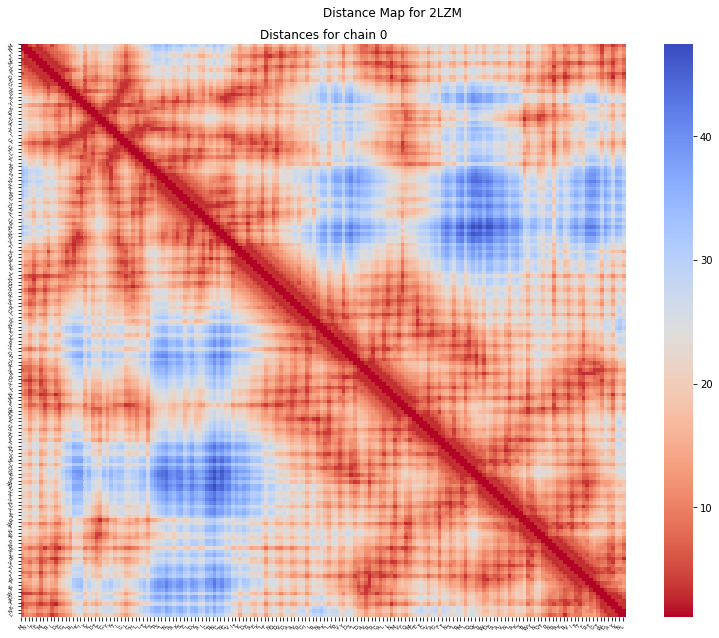

 11%|█████████▏                                                                      | 40/349 [00:00<00:00, 399.99it/s]

Parsing experimental mutations ...


  1%|█                                                                              | 42/3116 [00:00<00:07, 418.16it/s]

Parsing in silico mutations ...


100%|█████████████████████████████████████████████████████████████████████████████| 3116/3116 [00:06<00:00, 449.82it/s]


...

Matrix: BLOSUM45: : 164it [08:08,  2.98s/it]
Matrix: BLOSUM80: : 0it [00:00, ?it/s]

[[1.         0.99668741 0.99486815 ... 0.23949779 0.38335439 0.62790834]
 [0.99668741 1.         0.99619253 ... 0.23866296 0.38203194 0.62577536]
 [0.99486815 0.99619253 1.         ... 0.2382107  0.38131354 0.62461188]
 ...
 [0.23949779 0.23866296 0.2382107  ... 1.         0.50970882 0.18408792]
 [0.38335439 0.38203194 0.38131354 ... 0.50970882 1.         0.31572652]
 [0.62790834 0.62577536 0.62461188 ... 0.18408792 0.31572652 1.        ]]


Matrix: BLOSUM80: : 164it [07:58,  2.92s/it]


[[1.         0.99815456 0.99677207 ... 0.2370238  0.37695828 0.61418944]
 [0.99815456 1.         0.99738693 ... 0.23655798 0.37622426 0.61301506]
 [0.99677207 0.99738693 1.         ... 0.23621612 0.37568396 0.61214552]
 ...
 [0.2370238  0.23655798 0.23621612 ... 1.         0.43020578 0.1761187 ]
 [0.37695828 0.37622426 0.37568396 ... 0.43020578 1.         0.37695828]
 [0.61418944 0.61301506 0.61214552 ... 0.1761187  0.37695828 1.        ]]


No handles with labels found to put in legend.


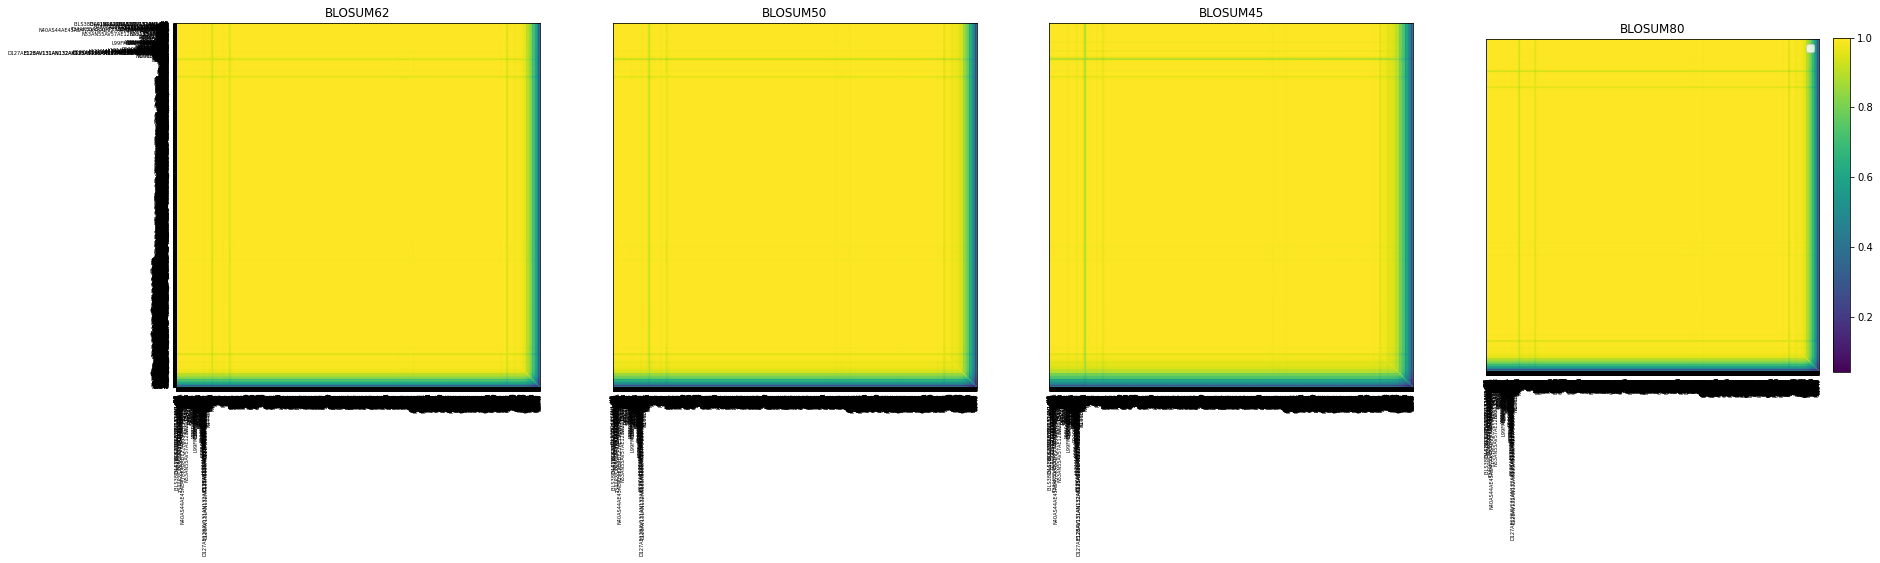

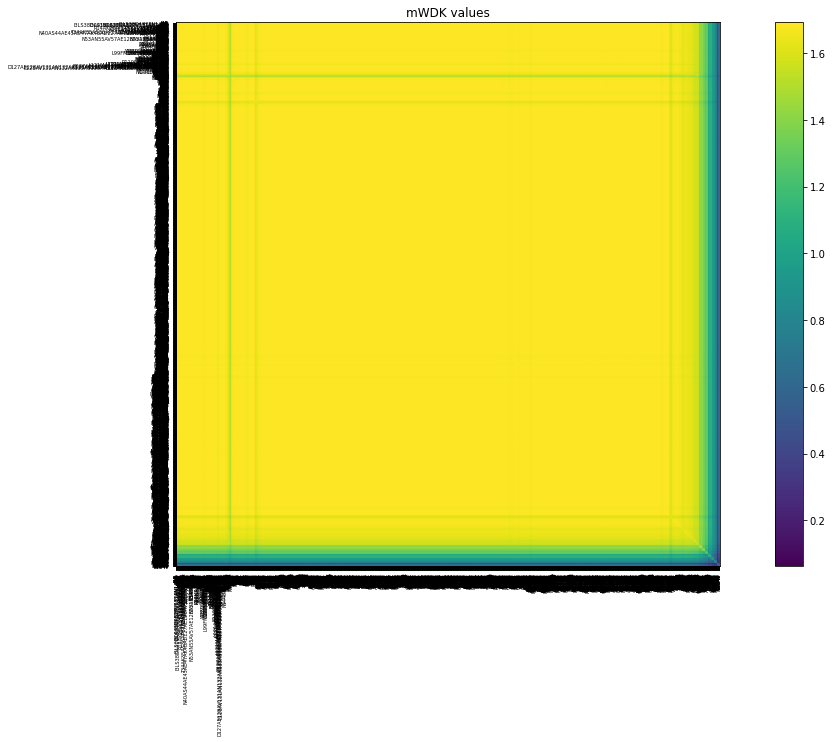

NameError: name 'BayesScaler' is not defined

In [4]:
# generate contactmaps, distance matrix plots
for pdb in pdbs:
    if pdb == "1BNI" or pdb == "1VQB":
        continue
    filename = f"/home/rcml/pdb/{pdb.lower()}.pdb"
    save_fig = "/home/rcml/pro_tooling/fig/"
    # create contact maps and dist-matrices ...
    cm1 = ContactMapper(pdb_file=filename)
    cm2 = ContactMapper(pdb_file=filename, tri_dist=True)
    #cm1.plot_distance_matrix(save_fig=save_fig)
    cm2.plot_distance_matrix(save_fig=save_fig)
    #cm1.plot_contact_map(save_fig=save_fig)
    #cm2.plot_contact_map(save_fig=save_fig)
    # get mutations for pdb
    exp_mutations = parse_mutations("/home/rcml/pro_tooling/data/ddg_protherm.mat", query="ddg_protherm")
    sim_mutations = parse_mutations("/home/rcml/pro_tooling/data/ddg_rosetta_single.mat", query="ddg_rosetta_single")
    # generate sub_matrices and representations ...
    pcol = ProteinCollection(cm2, pdb_ID=pdb, mutations_exp=exp_mutations, mutations_sim=sim_mutations)
    pcol.plot_sub_matrices(savefig=save_fig)
    pcol.plot_mwdk(savefig=save_fig)
    # Bayesian Scaling
    exp_mut = pcol.mutation_ids[:len(pcol.mut_S_exp)]
    is_mut = pcol.mutation_ids[len(pcol.mut_S_exp):]
    bs = BayesScaler(is_mutations=is_mut, ΔΔg=pcol.ΔΔg_is, 
                     exp_mutations=exp_mut, experimentally_observed_ΔΔg=pcol.ΔΔg_exp, 
                        TESTING=False, pdb_ID=pdb)
    bs.print_summary()
    bs.plot_scaling(save_fig=save_fig)
    
    

In [ ]:
# TODO compute Kernel matrices for each from mutations

In [ ]:
# TODO perform Regression for each

In [ ]:
# TODO scaling + regression

In [ ]:
# TODO compute correlation rho and rmse calculation